# **SYSTEM SETUP**

In [ ]:
!pip install -U datasets
!pip install pandas sentence-transformers faiss-cpu
!pip install transformers accelerate evaluate bert_score

# **RAG PIPELINE**

## **STEP-1: CREATING KNOWLEDGE BASE**

In [ ]:
from datasets import load_dataset, concatenate_datasets
from typing import List, Dict
from typing import Dict, Any, Tuple
import time
from transformers import pipeline
from typing import Optional, Dict
import faiss
from datasets import Dataset
import os
import pandas as pd
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
import nltk
nltk.download("punkt")
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize
from transformers import AutoTokenizer
import pandas as pd
import time
from tqdm import tqdm
import evaluate
from nltk import word_tokenize
import matplotlib.pyplot as plt
import string
bleu = evaluate.load("bleu")
bertscore = evaluate.load("bertscore")

from transformers import AutoTokenizer, AutoModel
import torch


import warnings
warnings.filterwarnings("ignore")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


### **STEP-1.1: DATA LOADING**

**OBSERVATION 1**: To create our knowledge base we have 2 different options. Either we can create knowledge base using an **open dataset** from Huggingface or we can use **our custom dataset**. The **"source"** parameter will handle this.

**OBESERVATION 2**: All open datasets are not sructured in the same way. Sometimes, they provide 2 different sets (train, test), or 3 different set (train, validation, test) or often only 1 (train). To keep our code modular, the **"split"** parameter will handle this.

**OBSERVATION 3**: If open dataset is too heavy to handle, the **"limit"** parameter will shirnk the dataset space for ease of experimentation.

Dataset that we can try: **squad**, **squad_v2**, **natural_questions**, **fiqa**, **hotpot_qa**, **trivia_qa**, **eli5**

In [ ]:
def load_knowledge_dataset(
    source: str,
    context_column: str = "context",
    split: str = None,
    limit: int = None
) -> Dataset:
    if os.path.exists(source) and source.endswith(".csv"):
        df = pd.read_csv(source)
        if context_column not in df.columns:
            raise ValueError(f"'{context_column}' column not found in CSV.")
        df = df[[context_column]]
        if limit:
            df = df.head(limit)
        return Dataset.from_pandas(df)

    dataset_dict = load_dataset(source)

    if split and split in dataset_dict:
        dataset = dataset_dict[split]
    elif split and split == "all":
        all_splits = [dataset_dict[split_name] for split_name in dataset_dict]
        dataset = concatenate_datasets(all_splits)
    elif "train" in dataset_dict:
        dataset = dataset_dict["train"]
    elif "validation" in dataset_dict:
        dataset = dataset_dict["validation"]
    else:
        dataset = list(dataset_dict.values())[0]

    if context_column not in dataset.column_names:
        raise ValueError(f"'{context_column}' column not found in dataset '{source}'. Available columns: {dataset.column_names}")

    dataset = dataset.to_pandas()
    dataset.drop_duplicates(subset=[context_column], keep='first', inplace=True)
    dataset = Dataset.from_pandas(dataset)

    if limit:
        dataset = dataset.select(range(limit))

    return dataset

### **STEP-1.2: TEXT SPLITTING**

In [ ]:
def extract_context_entries(dataset_dict) -> List[Dict]:
    entries = []
    for split_name, split_data in dataset_dict.items():
        for row in split_data:
            context = row.get("context", "").strip()
            if not context:
                continue
            entry = {
                "context": context,
                "id": row.get("id", f"{split_name}_{len(entries)}"),
                "title": row.get("title", split_name),
                "source_split": split_name
            }
            entries.append(entry)
    return entries

### **STEP-1.3: EMBEDDING**

Maximum number of words that will be considered in each chunk will be determined by the **"max_words"** parameter.

The overlapping bwtween two chunks will be determined the **"stride"** parameter.

In [ ]:
def chunk_generation(text: str, max_words=100, stride=50) -> list:
    sentences = sent_tokenize(text)
    chunks, current, word_count = [], [], 0
    for sent in sentences:
        words = sent.split()
        if word_count + len(words) > max_words:
            if current:
                chunks.append(" ".join(current))
                if stride:
                    current = current[-stride:]  # overlap
                    word_count = sum(len(s.split()) for s in current)
                else:
                    current = []
                    word_count = 0
        current.append(sent)
        word_count += len(words)

    if current:
        chunks.append(" ".join(current))
    return chunks

In [ ]:
def generate_chunked_passages(
    context_entries: List[Dict],
    max_words: int = 100,
    stride: int = 50
) -> List[Dict]:
    chunked_passages = []
    for entry in context_entries:
        chunks = chunk_generation(entry["context"], max_words=max_words, stride=stride)
        for i, chunk in enumerate(chunks):
            chunked_passages.append({
                "text": chunk,
                "source_id": entry.get("id", f"row_{i}"),
                "title": entry.get("title", "unknown"),
                "source_split": entry.get("source_split", "unknown"),
                "chunk_index": i
            })
    return chunked_passages

We can try different embedding model here:

**"sentence-transformers"** Backend: all-MiniLM-L6-v2, all-mpnet-base-v2, multi-qa-MiniLM-L6-cos-v1, multi-qa-mpnet-base-dot-v1, sentence-transformers/paraphrase-mpnet-base-v2, BAAI/bge-small-en

**"huggingface"** Backend: intfloat/e5-base, intfloat/e5-small-v2, princeton-nlp/sup-simcse-roberta-base, hkunlp/instructor-xl, thenlper/gte-small, jinaai/jina-embeddings-v2-small-en

In [ ]:
sentence_transformers_models = dict()
hugging_face_models = dict()
hugging_face_tokenizers = dict()

def embed_passages(
    texts: List[str],
    model_name: str = "all-MiniLM-L6-v2",
    backend: str = "sentence-transformers"
) -> np.ndarray:

    if backend == "sentence-transformers":
        if model_name not in sentence_transformers_models:
            sentence_transformers_models[model_name] = SentenceTransformer(model_name)
        model = sentence_transformers_models[model_name]
        embeddings = model.encode(texts, show_progress_bar=False)
    elif backend == "huggingface":
        if model_name not in hugging_face_models:
            hugging_face_models[model_name] = AutoModel.from_pretrained(model_name)
            hugging_face_tokenizers[model_name] = AutoTokenizer.from_pretrained(model_name)
        model = hugging_face_models[model_name]
        tokenizer = hugging_face_tokenizers[model_name]
        model.eval()
        embeddings = []
        with torch.no_grad():
            for text in texts:
                inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
                outputs = model(**inputs)
                sentence_embedding = outputs.last_hidden_state.mean(dim=1).squeeze().numpy()
                embeddings.append(sentence_embedding)
    else:
        raise ValueError(f"Unsupported backend: {backend}")
    return np.array(embeddings).astype("float32")

### **STEP-1.4: VECTOR DATABASE**

In [ ]:
def build_vector_database(
    chunked_passages: List[Dict],
    embeddings: np.ndarray
) -> Tuple[faiss.IndexFlatL2, Dict[int, Dict[str, Any]]]:
    if len(chunked_passages) != embeddings.shape[0]:
        raise ValueError("Mismatch between number of passages and embeddings.")
    dimension = embeddings.shape[1]
    index = faiss.IndexFlatL2(dimension)
    index.add(embeddings)
    passage_id_map = {i: chunked_passages[i] for i in range(len(chunked_passages))}
    return index, passage_id_map

### **STEP-1.5: MAIN FUNCTION**

In [ ]:
def create_knowledge_base(
    source: str,
    context_column: str = "context",
    split: str = None,
    limit: int = None,
    max_words: int = 100,
    stride: int = 50,
    model_name: str = "all-MiniLM-L6-v2",
    backend: str = "sentence-transformers"
) -> Tuple[faiss.IndexFlatL2, Dict[int, Dict[str, Any]]]:
    print("Loading dataset...")
    dataset = load_knowledge_dataset(source, context_column, split, limit)
    dataset_dict = {"user_split": dataset}

    print("Extracting context entries...")
    context_entries = extract_context_entries(dataset_dict)

    print("Chunking text...")
    chunked_passages = generate_chunked_passages(context_entries, max_words, stride)

    print("Embedding passages...")
    texts = [chunk["text"] for chunk in chunked_passages]
    embeddings = embed_passages(texts, model_name=model_name, backend=backend)

    print("Building vector database...")
    index, passage_id_map = build_vector_database(chunked_passages, embeddings)

    print(f"Knowledge base created with {len(chunked_passages)} chunks and dimension {embeddings.shape[1]}")
    return index, passage_id_map


## **STEP-2: RETRIEVER**

### **STEP-2.1: SEMANTIC SEARCH (RETRIEVE TOP-K CONTEXT)**

In [ ]:
def semantic_search(
    query: str,
    index: faiss.IndexFlatL2,
    passage_id_map: Dict[int, Dict],
    embedder_model: str = "all-MiniLM-L6-v2",
    backend: str = "sentence-transformers",
    k: int = 3
) -> List[Dict]:
    query_embedding = embed_passages([query], model_name=embedder_model, backend=backend)
    D, I = index.search(np.array(query_embedding).astype("float32"), k=k)

    results = []
    for score, idx in zip(D[0], I[0]):
        result = passage_id_map[idx].copy()
        result["similarity_score"] = float(score)
        results.append(result)

    return results

## **STEP-3: AUGMENTATION**

### **STEP-3.1: PROMPT FORMAT**

**Observation**: Diffent LLM models will allow different maximum number of tokens in the prompt. The following function will handle it efficiently. However, it is not proven yet until we run all experiment (at this moment it is just visionary let's see)

In [ ]:
class PromptBuilder:
    def __init__(self, model_name: str):
        self.model_name = model_name
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.max_tokens = self._get_max_input_tokens()

    def _get_max_input_tokens(self) -> int:
        if hasattr(self.tokenizer, "model_max_length") and self.tokenizer.model_max_length and self.tokenizer.model_max_length < 1e5:
            return self.tokenizer.model_max_length
        return 512

    def build(self, query: str, retrieved_chunks: List[Dict], style: str = "rag") -> str:
        context = "\n\n".join([chunk["text"] for chunk in retrieved_chunks])

        if style == "rag":
            prompt = f"""

You are a helpful assistant. Use the following context to answer the question.
Evaluate the context carefully before answering the question and give as
concise of an answer as you can. Think carefully about the answer before
replying. For example if you are asked the question. Where possible use
the exact text from the context to answer the question.
Here is an example:

=== Example Question ===
Question: What is the capital of Germany?

Context: Among the major European capitals, Berlin has the highest population.
This is because of its status as the economic powerhouse of Germany.

Answer: Berlin

Here is the question you are to answer and the context.
===

Question: {query}

Context: {context}

Answer:"""
        elif style == "instruction":
            prompt = f"""Answer the question based on the context.

[Question]:
{query}

[Context]:
{context}

[Answer]:"""
        elif style == "plain":
            prompt = f"{context}\n\nQuestion: {query}\nAnswer:"
        else:
            raise ValueError(f"Unsupported prompt style: {style}")

        return self._truncate(prompt)

    def _truncate(self, prompt: str) -> str:
        tokens = self.tokenizer(prompt, truncation=True, max_length=self.max_tokens, return_tensors="pt")
        return self.tokenizer.decode(tokens["input_ids"][0], skip_special_tokens=True)

## **STEP-4: GENERATION**

For Apples to Apples comparison try to keep the maximum tokens (max_tokens) generated in the response same. However, sometimes during writing report and position our interpretation, we may not be consistent. Let's @ Thomas Alva Edison decide it.

In [ ]:
def generate_answer(
    prompt: str,
    generator,
    model_name: str = "google/flan-t5-base",
    max_tokens: int = 200
) -> Dict[str, Optional[str]]:
    if not prompt.strip():
        return {"answer": None, "latency": None}
    start = time.time()
    try:
        response = generator(prompt, max_length=max_tokens, do_sample=False)
        answer = response[0]["generated_text"].strip()
        latency = time.time() - start
    except Exception as e:
        answer = f"[Error] {str(e)}"
        latency = None
    return {"answer": answer, "latency": latency}

## **STEP-5: EVALUATION**

In [ ]:
def normalize(text):
    return ''.join([c.lower() for c in text if c not in string.punctuation]).strip()
def f1_score(pred, true):
    pred_tokens = word_tokenize(normalize(pred))
    true_tokens = word_tokenize(normalize(true))
    common = set(pred_tokens) & set(true_tokens)
    if not common:
        return 0.0
    precision = len(common) / len(pred_tokens)
    recall = len(common) / len(true_tokens)
    return 2 * precision * recall / (precision + recall)
def exact_match(pred, true):
    return normalize(pred) == normalize(true)

In [ ]:
def evaluate_rag_pipeline(
    dataset,
    index,
    passage_id_map,
    embedder_model,
    backend,
    generator_pipeline,
    prompt_builder,
    num_samples=100,
    k=10,
    prompt_style="rag",
    max_tokens=100
):
    records = []
    subset = dataset.select(range(num_samples))
    for example in tqdm(subset):
        question = example["question"]
        ground_truth = example["answers"]["text"][0]
        retrieved = semantic_search(
            query=question,
            index=index,
            passage_id_map=passage_id_map,
            embedder_model=embedder_model,
            backend=backend,
            k=k
        )
        prompt = prompt_builder.build(query=question, retrieved_chunks=retrieved, style=prompt_style)

        try:
            start = time.time()
            result = generator_pipeline(prompt, max_length=max_tokens, do_sample=False)
            pred = result[0]["generated_text"].strip()
            latency = time.time() - start
        except Exception as e:
            pred = f"[Error] {str(e)}"
            latency = None
        records.append({
            "question": question,
            "ground_truth": ground_truth,
            "prediction": pred,
            "f1": f1_score(pred, ground_truth),
            "exact_match": exact_match(pred, ground_truth),
            "latency": latency
        })
    df = pd.DataFrame(records)
    bleu_score = bleu.compute(
        predictions=df["prediction"].tolist(),
        references=[[ref] for ref in df["ground_truth"].tolist()]
    )
    bert_score = bertscore.compute(
        predictions=df["prediction"].tolist(),
        references=df["ground_truth"].tolist(),
        lang="en"
    )
    df["bertscore"] = bert_score["f1"]
    print(f"\n Evaluation on {num_samples} RAG queries")
    print(f"Avg F1: {df['f1'].mean():.4f}, Avg EM: {df['exact_match'].mean():.4f}, Avg Latency: {df['latency'].mean():.2f}s")
    print(f"BLEU Score: {bleu_score['bleu']:.4f}")
    print(f"Avg BERTScore: {df['bertscore'].mean():.4f}")
    return df

In [ ]:
def plot_f1_distribution(df):
    plt.figure(figsize=(8, 4))
    plt.hist(df["f1"], bins=20, color='steelblue', edgecolor='black')
    plt.title("F1 Score Distribution")
    plt.xlabel("F1 Score")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

def show_low_performance(df, threshold=0.2):
    print("\nLow-performing cases:")
    print(df[df["f1"] < threshold][["question", "ground_truth", "prediction"]].head())

## **STEP-6: MAIN FUNCTION**

In [ ]:
def run_rag_pipeline(
    query: str,
    source: str = "squad",
    context_column: str = "context",
    split: str = "train",
    limit: int = 500,
    max_words: int = 100,
    stride: int = 50,
    embedder_model: str = "all-MiniLM-L6-v2",
    backend: str = "sentence-transformers",
    generator_model: str = "google/flan-t5-base",
    prompt_style: str = "rag",
    top_k: int = 10,
    max_tokens: int = 200,
    num_eval_samples: int = 100,
    evaluate: bool = True
):
    # Step 1: Build knowledge base
    index, passage_id_map = create_knowledge_base(
        source=source,
        context_column=context_column,
        split=split,
        limit=limit,
        max_words=max_words,
        stride=stride,
        model_name=embedder_model,
        backend=backend
    )

    # Step 2: Retrieve top-k context
    top_passages = semantic_search(
        query=query,
        index=index,
        passage_id_map=passage_id_map,
        embedder_model=embedder_model,
        backend=backend,
        k=top_k
    )

    # Step 3: Prompt building using model-aware truncation
    prompt_builder = PromptBuilder(model_name=generator_model)
    prompt = prompt_builder.build(query=query, retrieved_chunks=top_passages, style=prompt_style)
    print(prompt)

    generator = pipeline("text2text-generation", model=generator_model)

    # Step 4: Generate answer
    result = generate_answer(prompt, generator)

    print("\nDemo Query:", query)
    for i, passage in enumerate(top_passages):
        print(f"\nRank {i+1} | Score: {passage['similarity_score']:.2f}")
        print(passage["text"])
    print("\nPrompt:\n", prompt)
    print("\nGenerated Answer:", result["answer"])
    print(f"Latency: {result['latency']:.2f} seconds")

    # Step 5: Evaluation
    if evaluate:
        squad = load_dataset("squad")

        df = evaluate_rag_pipeline(
            dataset=squad["validation"],
            index=index,
            passage_id_map=passage_id_map,
            embedder_model=embedder_model,
            backend=backend,
            generator_pipeline=generator,
            prompt_builder=prompt_builder,
            num_samples=num_eval_samples,
            k=top_k,
            prompt_style=prompt_style,
            max_tokens=max_tokens
        )
        return df

    return None

Loading dataset...
Extracting context entries...
Chunking text...
Embedding passages...
Building vector database...
Knowledge base created with 1275 chunks and dimension 384
You are a helpful assistant. Use the following context to answer the question. Evaluate the context carefully before answering the question and give as concise of an answer as you can. Think carefully about the answer before replying. For example if you are asked the question. Where possible use the exact text from the context to answer the question. Here is an example: === Example Question === Question: What is the capital of German? Context: Among the major European capitals, Berlin has the highest population. This is because of it's status as the economic powerhouse of Germany. Answer: Berlin Here is the question you are to answer and the context. === Question: What is the capital of France? Context: Montpellier was among the most important of the 66 "villes de sûreté" that the Edict of 1598 granted to the Hugue

Device set to use cuda:0



Demo Query: What is the capital of France?

Rank 1 | Score: 1.09
Montpellier was among the most important of the 66 "villes de sûreté" that the Edict of 1598 granted to the Huguenots. The city's political institutions and the university were all handed over to the Huguenots. Tension with Paris led to a siege by the royal army in 1622. Peace terms called for the dismantling of the city's fortifications. A royal citadel was built and the university and consulate were taken over by the Catholic party. Even before the Edict of Alès (1629), Protestant rule was dead and the ville de sûreté was no more. [citation needed]

Rank 2 | Score: 1.26
In the course of the 10th century, the initially destructive incursions of Norse war bands into the rivers of France evolved into more permanent encampments that included local women and personal property. The Duchy of Normandy, which began in 911 as a fiefdom, was established by the treaty of Saint-Clair-sur-Epte between King Charles III of West Franci

100%|██████████| 1000/1000 [02:25<00:00,  6.88it/s]
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



 Evaluation on 1000 RAG queries
Avg F1: 0.6505, Avg EM: 0.5400, Avg Latency: 0.13s
BLEU Score: 0.2457
Avg BERTScore: 0.9433


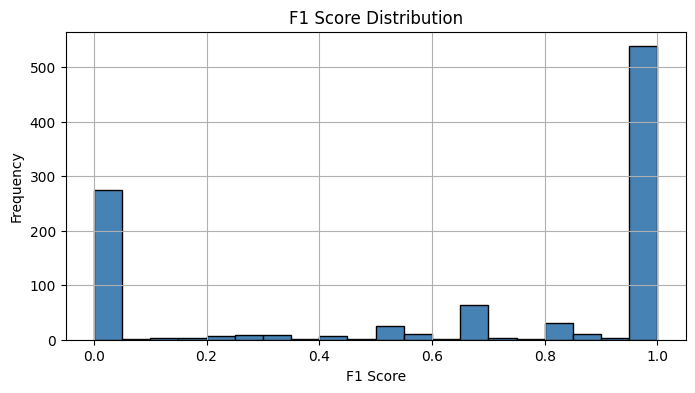


Low-performing cases:
                                             question  \
1   Which NFL team represented the NFC at Super Bo...   
2                 Where did Super Bowl 50 take place?   
16  What year did the Denver Broncos secure a Supe...   
21                       What year was Super Bowl 50?   
27                      Where was Super Bowl 50 held?   

                ground_truth                          prediction  
1          Carolina Panthers                      Denver Broncos  
2    Santa Clara, California                      Levi's Stadium  
16                      2015  Super Bowl appearances since 1995.  
21                      2015                                2016  
27  Santa Clara, California.              San Francisco Bay Area  


In [ ]:
query = "What is the capital of France?"
df_results = run_rag_pipeline(
    query=query,
    source="squad",
    context_column="context",
    split='validation',
    limit=1000,
    max_words=200,
    stride=50,
    embedder_model="all-MiniLM-L6-v2",
    backend="sentence-transformers",
    generator_model="google/flan-t5-base",
    prompt_style="rag",
    top_k=3,
    max_tokens=400,
    num_eval_samples=1000,
    evaluate=True
)

df_results.to_csv("rag_eval_results.csv", index=False)
plot_f1_distribution(df_results)
show_low_performance(df_results, threshold=0.2)

### Visualizations

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


def visualize_embeddings_pca_3d(texts, colors, sizes, model_name="all-MiniLM-L6-v2", backend="sentence-transformers"):
    """
    Computes embeddings, performs PCA, and visualizes the results in a 3D scatterplot.

    Args:
        texts: A list of strings.
        model_name: The name of the embedding model.
        backend: The backend to use for embedding computation.

    Returns:
        None (displays the visualization).
    """
    # 1. Compute Embeddings
    embeddings = embed_passages(texts, model_name=model_name, backend=backend)

    unique_embeddings, counts = np.unique(embeddings, axis=0, return_counts=True)
    count_map = {tuple(emb): count for emb, count in zip(unique_embeddings, counts)}
    identical_counts = np.array([count_map[tuple(emb)] for emb in embeddings]) + 1.0

    # 2. Perform PCA
    pca = PCA(n_components=3)
    pca_result = pca.fit_transform(embeddings)

    # 3. Create a DataFrame for plotting
    pca_df = pd.DataFrame(pca_result, columns=['PCA1', 'PCA2', 'PCA3'])
    pca_df['text'] = texts  # Add the original text for labels if needed

    # 4. Create 3D Scatterplot
    fig = plt.figure(figsize=(10, 8))  # Adjust figure size as needed
    ax = fig.add_subplot(111, projection='3d')

    # Scatter plot with optional color based on text
    scatter = ax.scatter(pca_df['PCA1'],
                         pca_df['PCA2'],
                         pca_df['PCA3'],
                         cmap="tab20",
                         s=sizes,
                         c=colors,
                         depthshade=False,
                         )

    z_min = pca_df['PCA3'].min()

    for x, y, z in zip(pca_df['PCA1'], pca_df['PCA2'], pca_df['PCA3']):
            ax.plot([x, x],
                    [y, y],
                    [z, z_min], color="black", linewidth=0.5)  # Line to the floor


    # Add labels or annotations if desired (e.g., using pca_df['text'])

    ax.set_xlabel('PCA1')
    ax.set_ylabel('PCA2')
    ax.set_zlabel('PCA3')
    ax.set_title('3D PCA Visualization of Embeddings')

    plt.show()

Loading dataset...
Extracting context entries...
Chunking text...
Embedding passages...
Building vector database...
Knowledge base created with 1275 chunks and dimension 384


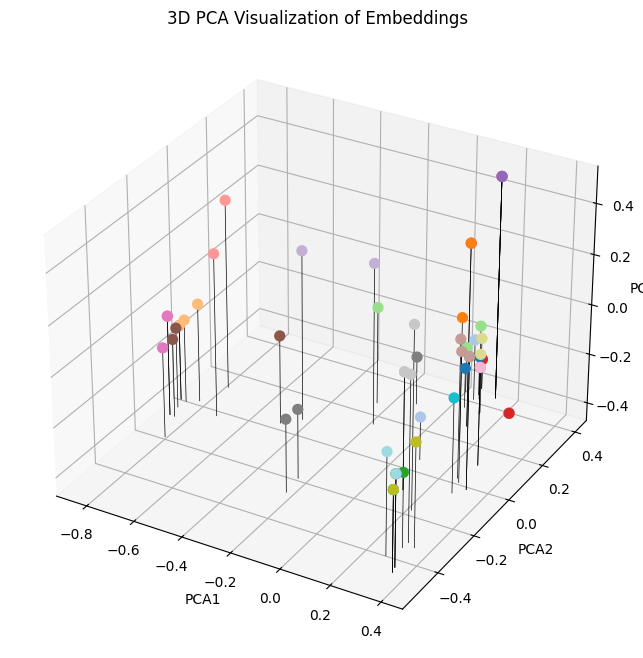

In [ ]:
index, passage_id_map = create_knowledge_base(
    source="squad",
    context_column="context",
    split='validation',
    limit=1000,
    max_words=200,
    stride=50,
    model_name="all-MiniLM-L6-v2",
    backend="sentence-transformers"
)
# 1. Get the bottom 10 results based on F1 score
df_bottom_10 = df_results.sample(20)

# 2. Find semantically similar passages using semantic_search
similar_passages = []
color_map = {}  # Dictionary to store color mapping

for i, question in enumerate(df_bottom_10["question"]):
    color_map[question] = i  # You can use any color mapping scheme here

all_colors = []
all_sizes = []
for _, row in df_bottom_10.iterrows():
    query = row["question"]
    retrieved = semantic_search(
        query=query,
        index=index,  # Assuming you have the index from create_knowledge_base
        passage_id_map=passage_id_map,  # Assuming you have the passage_id_map
        embedder_model="all-MiniLM-L6-v2",
        backend="sentence-transformers",
        k=3  # Retrieve top 5 similar passages
    )

    # query_embedding = embed_passages([query], model_name="all-MiniLM-L6-v2", backend="sentence-transformers")
    # similar_passages.append(query_embedding)
    # all_colors.append(color_map[query])
    # all_sizes.append(80)

    similar_passages.extend([r["text"] for r in retrieved])
    all_colors.extend([color_map[query]] * len(retrieved)) # Assign the same color to similar passages
    all_sizes.extend([50] * len(retrieved))


# 3. Visualize
visualize_embeddings_pca_3d(similar_passages,all_colors,all_sizes, model_name="all-MiniLM-L6-v2", backend="sentence-transformers")

Loading dataset...
Extracting context entries...
Chunking text...
Embedding passages...
Building vector database...
Knowledge base created with 1275 chunks and dimension 384


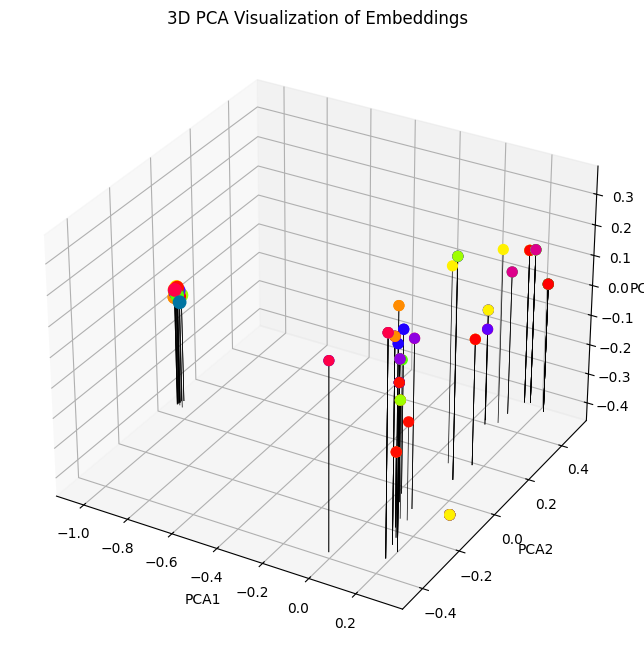

In [ ]:
index, passage_id_map = create_knowledge_base(
    source="squad",
    context_column="context",
    split='validation',
    limit=1000,
    max_words=200,
    stride=50,
    model_name="all-MiniLM-L6-v2",
    backend="sentence-transformers"
)
# 1. Get the bottom 10 results based on F1 score
df_bottom_10 = df_results.nlargest(20, "f1")

# 2. Find semantically similar passages using semantic_search
similar_passages = []
color_map = {}  # Dictionary to store color mapping

for i, question in enumerate(df_bottom_10["question"]):
    color_map[question] = i  # You can use any color mapping scheme here

all_colors = []
all_sizes = []
for _, row in df_bottom_10.iterrows():
    query = row["question"]
    retrieved = semantic_search(
        query=query,
        index=index,  # Assuming you have the index from create_knowledge_base
        passage_id_map=passage_id_map,  # Assuming you have the passage_id_map
        embedder_model="all-MiniLM-L6-v2",
        backend="sentence-transformers",
        k=5  # Retrieve top 5 similar passages
    )

    query_embedding = embed_passages([query], model_name="all-MiniLM-L6-v2", backend="sentence-transformers")
    similar_passages.append(query_embedding)
    all_colors.append(color_map[query])
    all_sizes.append(80)

    similar_passages.extend([r["text"] for r in retrieved])
    all_colors.extend([color_map[query]] * len(retrieved)) # Assign the same color to similar passages
    all_sizes.extend([50] * len(retrieved))


# 3. Visualize
visualize_embeddings_pca_3d(similar_passages,all_colors,all_sizes, model_name="all-MiniLM-L6-v2", backend="sentence-transformers")

# **WITHOUT RAG PIPELINE**

In [ ]:
#from datasets import load_dataset
from datasets import load_dataset as load_hf_dataset
from transformers import pipeline
import pandas as pd
import nltk
nltk.download('punkt_tab')
from nltk import word_tokenize
import matplotlib.pyplot as plt
import string
import time
import evaluate
bleu = evaluate.load("bleu")
bertscore = evaluate.load("bertscore")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## **STEP-1: DATA LOADING**

Dataset that we can try: ***squad***, ***squad_v2***, ***natural_questions***, ***fiqa***, ***hotpot_qa***, ***trivia_qa***, ***eli5***

In [ ]:
def load_dataset(name="squad", split="validation"):
    return load_hf_dataset(name)[split]

## **STEP-2: GENERATION MODEL**

Models that we can try:

**Pipeline: "text2text-generation"**

google/flan-t5-small, google/t5-v1_1-small, t5-small, sshleifer/distilbart-cnn-12-6, facebook/bart-base

**Pipeline: "text-generation"**

distilgpt2, tiiuae/falcon-rw-1b, EleutherAI/gpt-neo-125M

In [ ]:
def load_generator(model_name="google/flan-t5-base"):
    return pipeline("text2text-generation", model=model_name)

## **STEP-3: PROMPT DESIGN**

Prompt is another parameter to capture variance in performance. We will try 3 different prompt styles:

**1) flan 2) instruction 3) raw**

In [ ]:
def build_prompt(question: str, style: str = "flan") -> str:
    if style == "instruction":
        return f"Answer the question briefly.\n\nQuestion: {question}\nAnswer:"
    elif style == "flan":
        return f"Question: {question}\nAnswer:"
    else:
        return question

## **STEP-4: EVALUATION**

**EVALUATION PARAMETER 1: EM**

EM = 1; Exact Same Answer

EM = 0; Not Exact Answer (even for minor mismatches)

**EVALUATION PARAMETER 2: F1**

F1 = High (Good Semantic Similarity)

F1 = Low (Low Semantic Similarity)

**EVALUATION PARAMETER 3: Latency**

Latency = Low (Hardware Efficient)

Latency = High (Hardware Inefficient)

**EVALUATION PARAMETER 4: BERTscore**

BERTscore = High (Good Semantic Similarity)

BERTscore = Low (Low Semantic Similarity)

**EVALUATION PARAMETER 5: BELUscore**

BELUscore = High (Good Semantic Similarity)

BELUscore = Low (Low Semantic Similarity)


In [ ]:
def normalize(text):
    return ''.join([c.lower() for c in text if c not in string.punctuation]).strip()

def f1_score(pred, true):
    pred_tokens = word_tokenize(normalize(pred))
    true_tokens = word_tokenize(normalize(true))
    common = set(pred_tokens) & set(true_tokens)
    if not common:
        return 0.0
    precision = len(common) / len(pred_tokens)
    recall = len(common) / len(true_tokens)
    return 2 * precision * recall / (precision + recall)

def exact_match(pred, true):
    return normalize(pred) == normalize(true)

**Number of samples (num_samples)** indicates how many questions we will consider while evaluating our model.

**Maximum number of tokens (max_tokens)** indicates how many tokens the model will generate per answer.

***For apples to apples comparison we will keep this consistent in the entire experiment.***

In [ ]:
def evaluate_vanilla(generator_pipeline, dataset, num_samples=100, prompt_style="flan", max_tokens=100):
    from tqdm import tqdm
    records = []
    subset = dataset.select(range(num_samples))

    for ex in tqdm(subset):
        q = ex["question"]
        true = ex["answers"]["text"][0]
        prompt = build_prompt(q, prompt_style)

        try:
            start = time.time()
            pred = generator_pipeline(prompt, max_length=max_tokens, do_sample=False)[0]["generated_text"]
            latency = time.time() - start
        except:
            pred = ""
            latency = None

        records.append({
            "question": q,
            "ground_truth": true,
            "prediction": pred,
            "f1": f1_score(pred, true),
            "exact_match": exact_match(pred, true),
            "latency": latency
        })

    df = pd.DataFrame(records)

    bleu_score = bleu.compute(predictions=df["prediction"].tolist(),
                              references=[[ref] for ref in df["ground_truth"].tolist()])

    bert_score = bertscore.compute(predictions=df["prediction"].tolist(),
                                   references=df["ground_truth"].tolist(), lang="en")

    df["bertscore"] = bert_score["f1"]

    print(f"\n Evaluation ({num_samples} samples)")
    print(f"Avg F1: {df['f1'].mean():.4f}, Avg EM: {df['exact_match'].mean():.4f}, Avg Latency: {df['latency'].mean():.2f}s")
    print(f"BLEU Score: {bleu_score['bleu']:.4f}")
    print(f"Avg BERTScore: {df['bertscore'].mean():.4f}")

    return df

These are rudimentary visualizations. In course of time, we will find directions to generate interpretable visuals to for our report.

In [ ]:
def plot_f1_distribution(df):
    plt.figure(figsize=(8, 4))
    plt.hist(df["f1"], bins=20, color='steelblue', edgecolor='black')
    plt.title("F1 Score Distribution")
    plt.xlabel("F1 Score")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

def show_low_performance(df, threshold=0.2):
    print("\nLow-performing cases:")
    print(df[df["f1"] < threshold][["question", "ground_truth", "prediction"]].head())

## **MAIN FUNCTION**

**Experiment Space**: Dataset, Model, Prompt, Number of Samples, Number of tokens

**Observation Space**: EM, F1, Latency, BERTscore, BELUscore

**Interpretation/Key Takeways**: Look at the report by @Thomas Alva Edison

In [ ]:
def run_experiment(dataset_name="squad", model_name="google/flan-t5-base", prompt_style="flan", sample_size=1000, max_tokens=400):
    dataset = load_dataset(dataset_name)
    model = load_generator(model_name)
    df = evaluate_vanilla(model, dataset, num_samples=sample_size, prompt_style=prompt_style, max_tokens=max_tokens)
    plot_f1_distribution(df)
    show_low_performance(df)
    df.to_csv(f"results_{dataset_name.replace('/', '_')}_{model_name.replace('/', '_')}_{prompt_style}.csv", index=False)
    return df

Device set to use cuda:0
100%|██████████| 1000/1000 [02:56<00:00,  5.68it/s]
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



 Evaluation (1000 samples)
Avg F1: 0.0531, Avg EM: 0.0250, Avg Latency: 0.17s
BLEU Score: 0.0000
Avg BERTScore: 0.8585


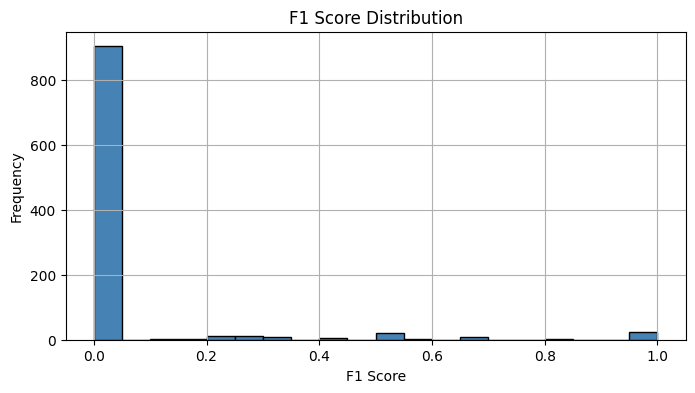


Low-performing cases:
                                            question             ground_truth  \
0  Which NFL team represented the AFC at Super Bo...           Denver Broncos   
1  Which NFL team represented the NFC at Super Bo...        Carolina Panthers   
2                Where did Super Bowl 50 take place?  Santa Clara, California   
3                  Which NFL team won Super Bowl 50?           Denver Broncos   
4  What color was used to emphasize the 50th anni...                     gold   

           prediction  
0        alabama rams  
1  st louis cardinals  
2           san diego  
3  san diego chargers  
4                 red  


In [ ]:
df = run_experiment("squad", "google/flan-t5-base", prompt_style="flan", sample_size=1000)